# Microsoft Stock Data Analysis

Use **yfinance** to download MSFT data, **NumPy** to hold the dates and adjusted-close prices, and **Matplotlib** to visualize the time series on a single chart and across multiple sub-charts.

In [9]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [10]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

## Load Microsoft stock data

In [11]:
ticker = 'MSFT'
start_date = '2023-01-01'
end_date = '2024-01-01'

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

if df.columns.nlevels > 1:
    df.columns = df.columns.droplevel(1)

time_series_data = df['Adj Close'].to_numpy()
time_series_dates = df.index.to_numpy()

print(f"NumPy time series for {ticker}:\n")
print("Dates (first 5):\n", time_series_dates[:5])
print("\nPrices (first 5):\n", time_series_data[:5])

[*********************100%***********************]  1 of 1 completed

NumPy time series for MSFT:

Dates (first 5):
 ['2023-01-03T00:00:00' '2023-01-04T00:00:00' '2023-01-05T00:00:00'
 '2023-01-06T00:00:00' '2023-01-09T00:00:00']

Prices (first 5):
 [232.51054382 222.33976746 215.75013733 218.29278564 220.41822815]


## Plot 1 — Single graph

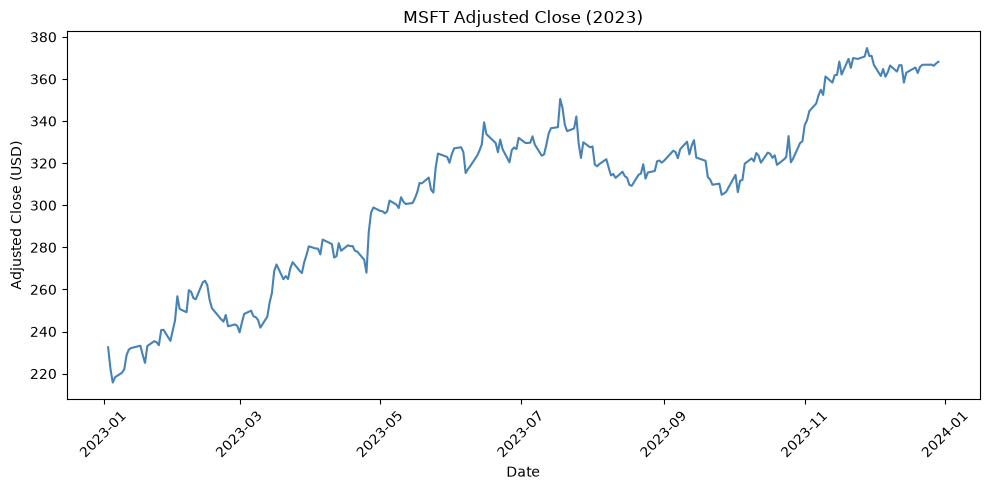

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_series_dates, time_series_data, color='steelblue')
ax.set_title(f'{ticker} Adjusted Close (2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plot 2 — Separate sub-charts

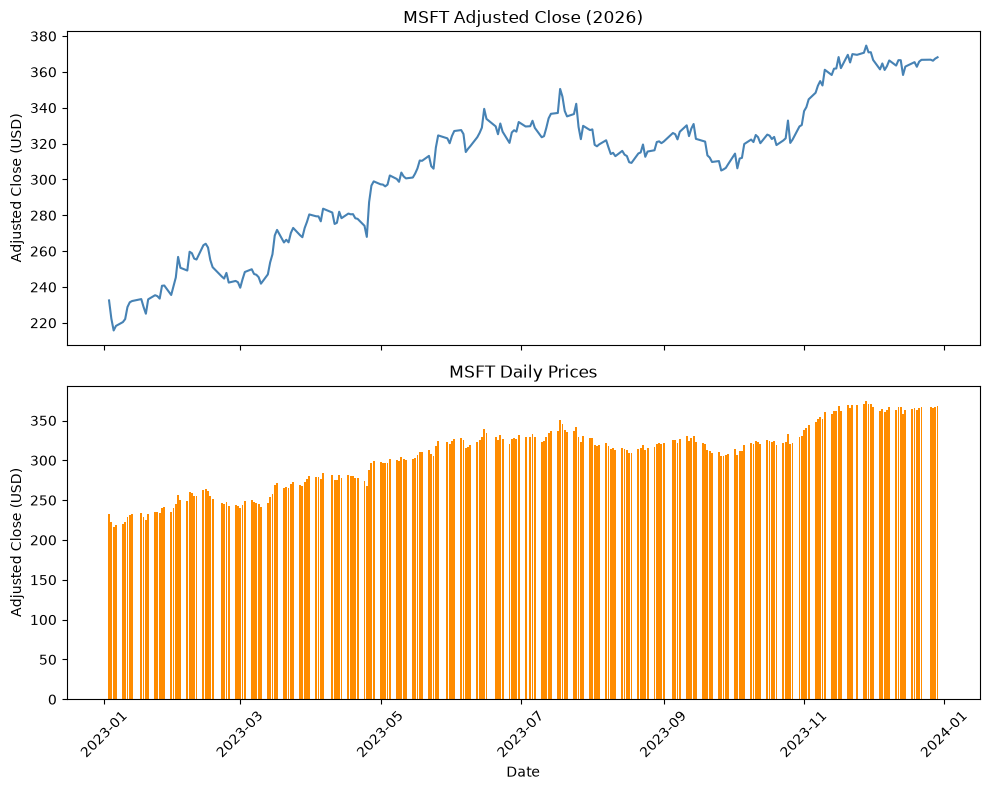

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(time_series_dates, time_series_data, color='steelblue')
axes[0].set_title(f'{ticker} Adjusted Close (2026)')
axes[0].set_ylabel('Adjusted Close (USD)')

numeric_dates = mdates.date2num(time_series_dates)
axes[1].bar(numeric_dates, time_series_data, color='darkorange', width=0.8)
axes[1].set_title(f'{ticker} Daily Prices')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Adjusted Close (USD)')
axes[1].xaxis_date()

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()